# Figure 2: Phase-Separation Kinetics and Composition Statistics

Reproduces Figure 2A,C-E from Shrinivas & Brenner (PNAS 2021).

In [1]:
# Colab setup:
# from google.colab import drive
# drive.mount('/content/drive')
#
# import sys
# sys.path.insert(0, '/content/drive/MyDrive/phase_separation')
#
# !cp -r "/content/drive/MyDrive/phase_separation" /content/phase_separation
# %cd phase_separation
# !ls
# !pip install -r requirements.txt
# !pip install jax-tqdm scikit-learn

import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/phase_separation
jax_phase_separation  phase_separation	requirements.txt


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import time

from jax_phase_separation.utils import (
    generate_chi_matrix, generate_initial_conditions, build_params,
    plot_phase_map,
)
from jax_phase_separation.solver import simulate_with_snapshots
from jax_phase_separation.analysis import analyse_snapshot

print('JAX version:', jax.__version__)

JAX version: 0.7.2


## Parameters

N=16 components, chi ~ Normal(0, sigma=4.8), equimolar.

In [3]:
N_COM = 16
N_GRID = 64
SIGMA = 4.8
BETA = N_COM / (N_COM + 1.0)
DT = 5e-6
LMBDA = 0.01
N_STEPS = 2_000_000
N_REPLICATES = 5
# Save snapshots at these analysis checkpoints
SAVE_EVERY = 50_000  # 40 snapshots over the run

## Run replicate trajectories

Each replicate draws a fresh `chi` matrix with the same macro parameters.

In [4]:
master_key = jax.random.PRNGKey(0)
keys = jax.random.split(master_key, N_REPLICATES * 2).reshape(N_REPLICATES, 2, -1)

all_n_phases_time = []  # list of (n_snapshots,) arrays
all_angles = []
all_n_enriched = []
example_snapshots = None
example_idx = 0  # which replicate to use for temporal snapshots

for rep in range(N_REPLICATES):
    k_chi = keys[rep, 0]
    k_ic = keys[rep, 1]

    chi = generate_chi_matrix(N_COM, 0.0, SIGMA, k_chi)
    c0 = generate_initial_conditions(N_COM, N_GRID, beta=BETA, noise_strength=0.01, key=k_ic)
    params = build_params(chi, N_COM, beta=BETA, lmbda=LMBDA, dt=DT)

    t0 = time.time()
    c_final, snaps = simulate_with_snapshots(
        c0, params, N_GRID, N_STEPS, save_every=SAVE_EVERY, progress_bar=True,
    )
    elapsed = time.time() - t0

    # Analyse each snapshot for number of phases
    n_ph_over_time = []
    for t_idx in range(snaps.shape[0]):
        res = analyse_snapshot(np.array(snaps[t_idx]))
        n_ph_over_time.append(res['n_phases'])
    all_n_phases_time.append(n_ph_over_time)

    # Steady-state statistics
    ss_result = analyse_snapshot(np.array(c_final))
    all_angles.extend(ss_result['angles'])
    all_n_enriched.extend(ss_result['n_enriched'].tolist())

    if rep == example_idx:
        example_snapshots = np.array(snaps)
        example_ss = ss_result

    if (rep + 1) % 5 == 0:
        print(f'  Replicate {rep+1}/{N_REPLICATES} done ({elapsed:.1f}s, '
              f'{ss_result["n_phases"]} phases)')

all_n_phases_time = np.array(all_n_phases_time)  # (N_REP, n_snapshots)
print(f'\nAll {N_REPLICATES} replicates completed.')

Running for 40 iterations:   0%|          | 0/40 [00:00<?, ?it/s]

Running for 40 iterations:   0%|          | 0/40 [00:00<?, ?it/s]

Running for 40 iterations:   0%|          | 0/40 [00:00<?, ?it/s]

Running for 40 iterations:   0%|          | 0/40 [00:00<?, ?it/s]

Running for 40 iterations:   0%|          | 0/40 [00:00<?, ?it/s]

  Replicate 5/5 done (305.5s, 3 phases)

All 5 replicates completed.


## Figure 2A: Number of phases vs time

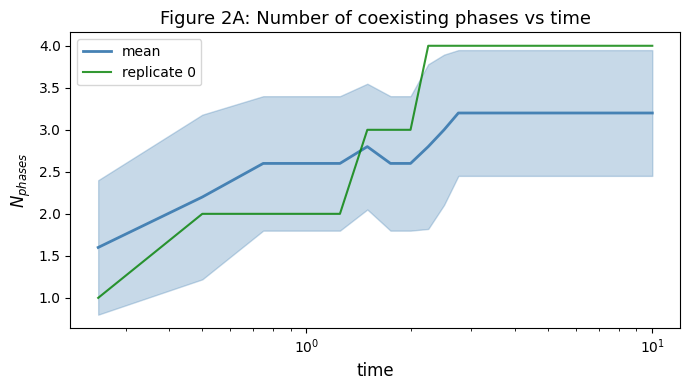

In [5]:
t_axis = np.arange(1, all_n_phases_time.shape[1] + 1) * SAVE_EVERY * DT

mean_ph = all_n_phases_time.mean(axis=0)
std_ph = all_n_phases_time.std(axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.fill_between(t_axis, mean_ph - std_ph, mean_ph + std_ph, alpha=0.3, color='steelblue')
ax.plot(t_axis, mean_ph, color='steelblue', lw=2, label='mean')
# Highlight the example trajectory
ax.plot(t_axis, all_n_phases_time[example_idx], color='green', lw=1.5,
        alpha=0.8, label=f'replicate {example_idx}')
ax.set_xscale('log')
ax.set_xlabel('time', fontsize=12)
ax.set_ylabel('$N_{phases}$', fontsize=12)
ax.set_title('Figure 2A: Number of coexisting phases vs time', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## Figure 2C: Angle distribution between coexisting phases

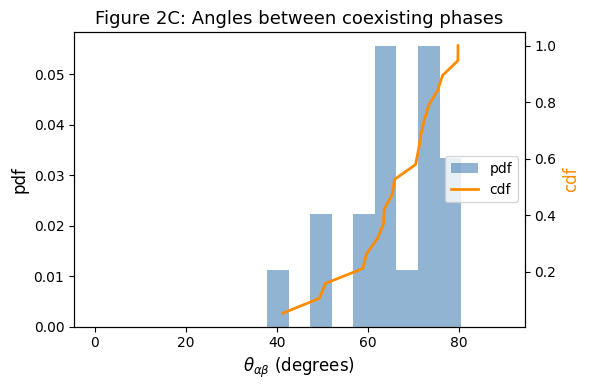

In [6]:
angles_arr = np.array(all_angles)

fig, ax1 = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, 90, 20)
counts, edges, _ = ax1.hist(angles_arr, bins=bins, density=True, alpha=0.6,
                             color='steelblue', label='pdf')
ax1.set_xlabel('$\\theta_{\\alpha\\beta}$ (degrees)', fontsize=12)
ax1.set_ylabel('pdf', fontsize=12)

ax2 = ax1.twinx()
sorted_angles = np.sort(angles_arr)
cdf = np.arange(1, len(sorted_angles) + 1) / len(sorted_angles)
ax2.plot(sorted_angles, cdf, color='darkorange', lw=2, label='cdf')
ax2.set_ylabel('cdf', fontsize=12, color='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax1.set_title('Figure 2C: Angles between coexisting phases', fontsize=13)
plt.tight_layout()
plt.show()

## Figure 2D: Distribution of enriched components per phase

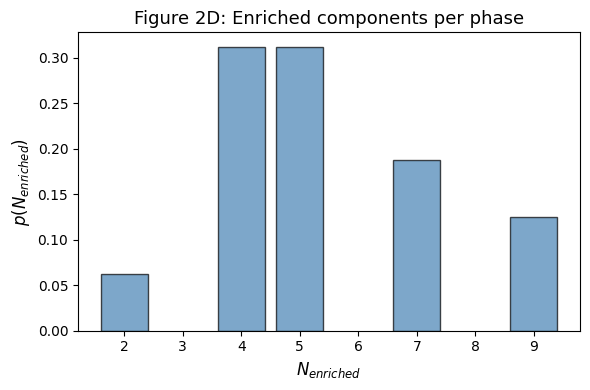

In [7]:
n_enr_arr = np.array(all_n_enriched)

fig, ax = plt.subplots(figsize=(6, 4))
vals, counts = np.unique(n_enr_arr, return_counts=True)
probs = counts / counts.sum()
ax.bar(vals, probs, color='steelblue', alpha=0.7, edgecolor='k')
ax.set_xlabel('$N_{enriched}$', fontsize=12)
ax.set_ylabel('$p(N_{enriched})$', fontsize=12)
ax.set_title('Figure 2D: Enriched components per phase', fontsize=13)
plt.tight_layout()
plt.show()

## Figure 2E: Temporal snapshots with phase labels

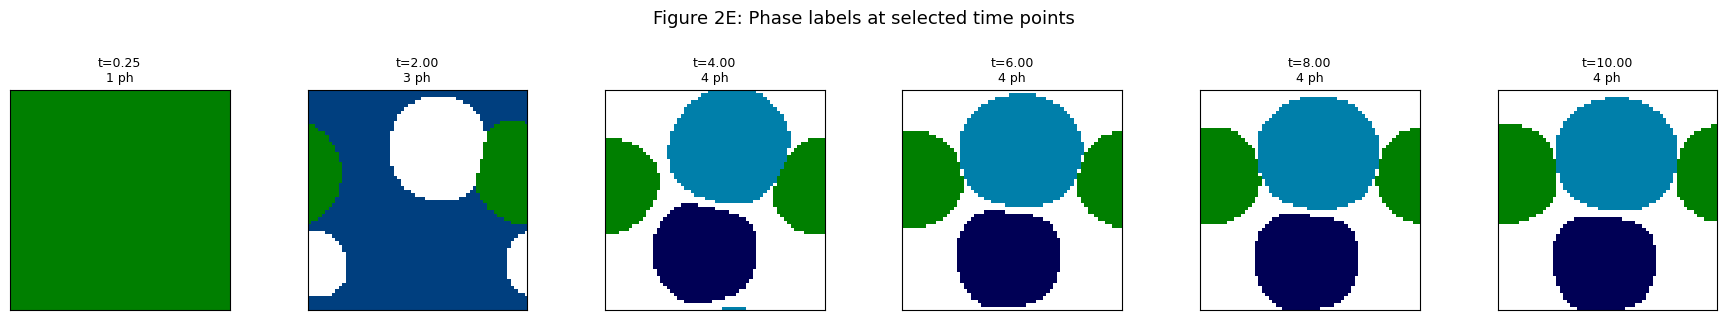

In [8]:
# Pick 6 time indices spread across the trajectory
n_snaps = example_snapshots.shape[0]
snap_indices = np.linspace(0, n_snaps - 1, 6, dtype=int)
snap_times = (snap_indices + 1) * SAVE_EVERY * DT

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, (si, st) in enumerate(zip(snap_indices, snap_times)):
    res = analyse_snapshot(example_snapshots[si])
    ax = axes[i]
    cmap = plt.get_cmap('ocean', max(res['n_phases'], 2))
    ax.imshow(res['labels'], cmap=cmap, origin='lower', interpolation='nearest')
    ax.set_title(f't={st:.2f}\n{res["n_phases"]} ph', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('Figure 2E: Phase labels at selected time points', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()